In [1]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from tqdm import tqdm_notebook
from itertools import product
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

6. 주어진 test_1.npy 시계열을 시각화하여 확인하고, 정상성 테스트를 수행한 뒤 정상시계열이 아니면 차분을 적용하여 다시 정상성 테스트를 수행하는 코드를 작성하시오

In [2]:
process = np.load("test_1.npy")

In [3]:
process.shape

(1000,)

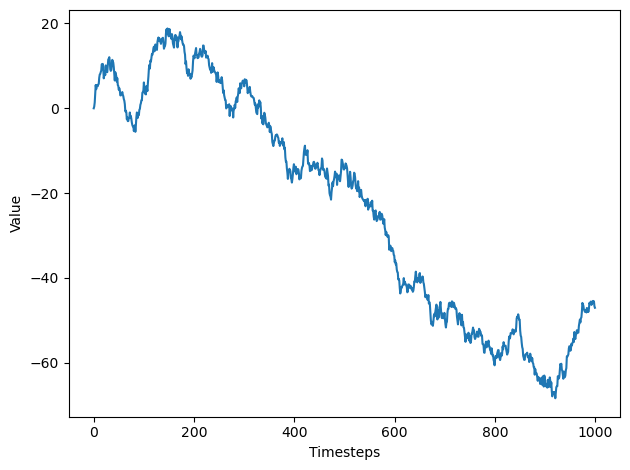

In [4]:
fig, ax = plt.subplots()

ax.plot(process)

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [5]:
result = adfuller(process)

print(result[1])

0.8831939389121152


In [6]:
process_diff = np.diff(process, n = 1)

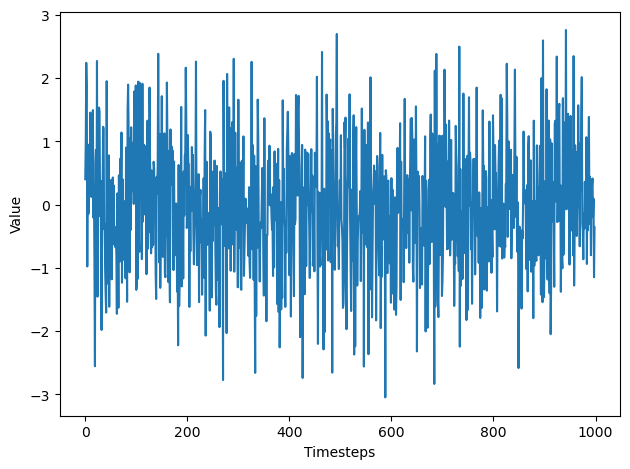

In [7]:
fig, ax = plt.subplots()

ax.plot(process_diff)

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [8]:
result = adfuller(process_diff)

print(result[1])

0.0


7. ACF와 PACF를 활용하여 주어진 test_2.npy 시계열이 AR 프로세스인지 MA 프로세스인지 판단하는 코드를 작성하고, 적절한 차수(p 또는 q)를 제시하시오

In [9]:
process = np.load("test_2.npy")

In [10]:
process.shape

(1000,)

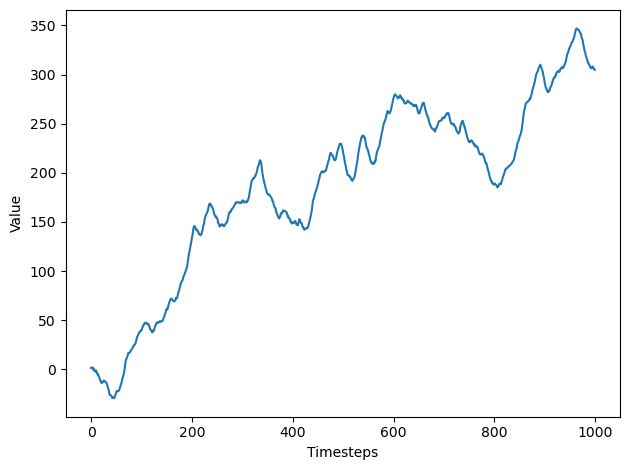

In [11]:
fig, ax = plt.subplots()

ax.plot(process)

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [12]:
result = adfuller(process)
print(result[1])

0.45249034449739356


In [13]:
process_diff = np.diff(process, n = 1)

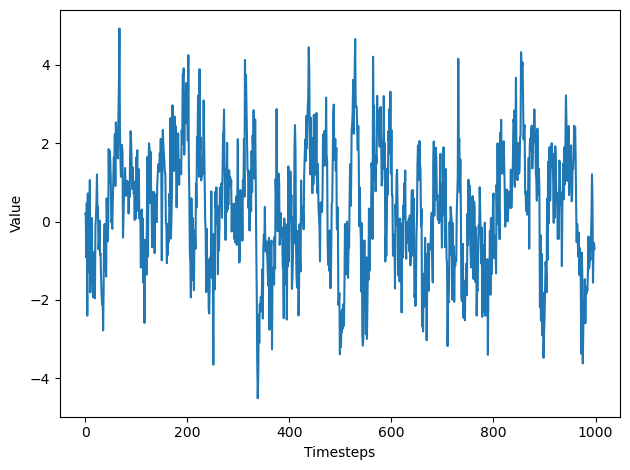

In [14]:
fig, ax = plt.subplots()

ax.plot(process_diff)

ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [15]:
result = adfuller(process_diff)

print(result[1])

2.6460503833673623e-11


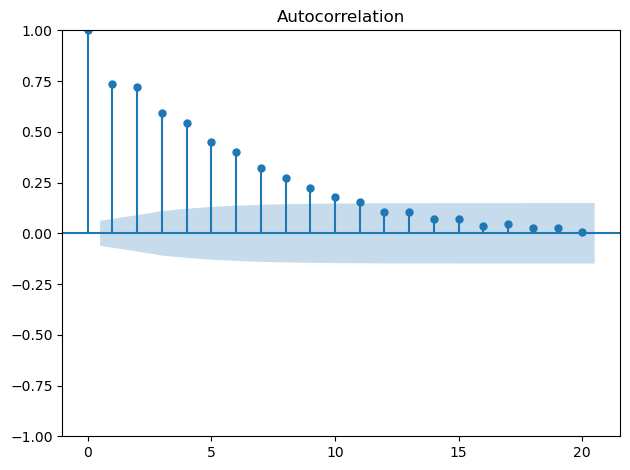

In [16]:
plot_acf(process_diff, lags = 20)

plt.tight_layout()
plt.show()

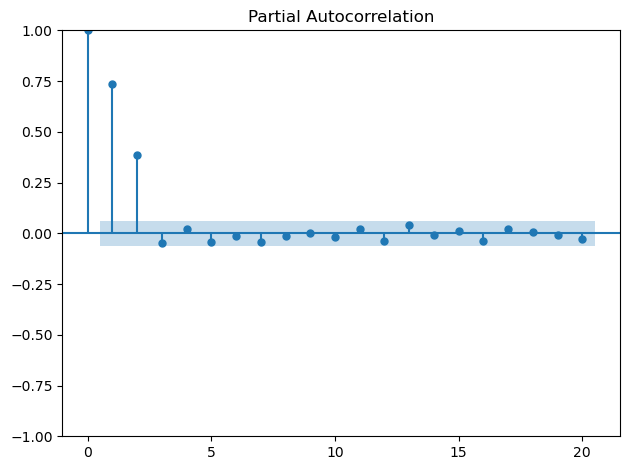

In [17]:
plot_pacf(process_diff, lags = 20)

plt.tight_layout()
plt.show()

- 결론 : AR(2) 모델

8.  주어진 bandwidth.csv 데이터의 마지막 168timesteps에 대해 예측을 수행하는 코드를 작성하시오(필수적인 코드만 답안으로 작성)

In [18]:
df = pd.read_csv("bandwidth.csv")

In [19]:
df.head()

,hourly_bandwidth
0,1000.496714
1,1000.969408
2,1002.046019
3,1004.702118
4,1007.447816


In [20]:
df.shape

(10000, 1)

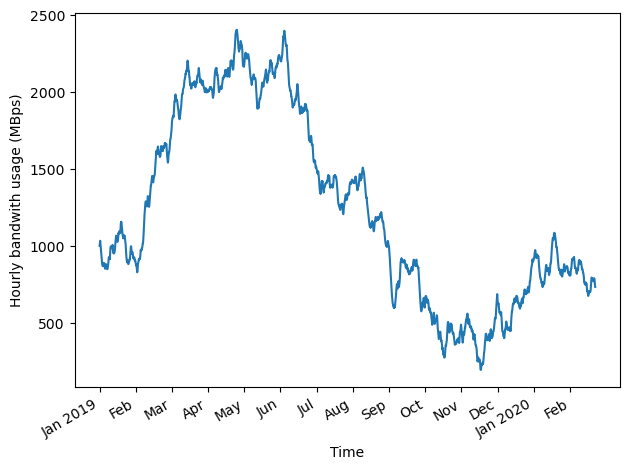

In [21]:
fig, ax = plt.subplots()

ax.plot(df['hourly_bandwidth'])
ax.set_xlabel('Time')
ax.set_ylabel('Hourly bandwith usage (MBps)')

plt.xticks(
    np.arange(0, 10000, 730), 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan 2020', 'Feb'])

fig.autofmt_xdate()
plt.tight_layout()

plt.show()

In [22]:
ad_fuller_result = adfuller(df["hourly_bandwidth"])

print(f"ADF Statistic: {ad_fuller_result[0]}")
print(f"p-value: {ad_fuller_result[1]}")

ADF Statistic: -0.8714653199452604
p-value: 0.7972240255014593


In [23]:
df_diff = np.diff(df["hourly_bandwidth"], n = 1)

In [24]:
ad_fuller_result = adfuller(df_diff)

print(f"ADF Statistic: {ad_fuller_result[0]}")
print(f"p-value: {ad_fuller_result[1]}")

ADF Statistic: -20.69485386378902
p-value: 0.0


- 1차 차분 이후 정상성을 만족하므로 d = 1

In [25]:
train = df[:-168]
test = df[-168:]

In [26]:
print(len(train))

9832


In [27]:
ps = range(0, 4, 1)
qs = range(0, 4, 1)
d = 1

order_list = list(product(ps, qs))
order_list

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3)]

In [28]:
def optimize_ARIMA(endog: Union[pd.Series, list], order_list: list, d: int) -> pd.DataFrame:
    '''
    endog : 예측하고자 하는 대상 시계열 데이터
    order_list : p, q 조합 리스트
    d : 적분 차수
    '''
    results = [] # 차수 p, q와 그에 해당하는 AIC를 저장할 리스트

    for order in tqdm_notebook(order_list):
        try:
            model = SARIMAX(endog, order = (order[0], d, order[1])).fit(disp = False)

        except:
            continue

        aic = model.aic # 모델의 AIC를 계산
        results.append([order, aic]) # 결과 리스트에 p, q 조합과 AIC를 추가

    result_df = pd.DataFrame(results)
    result_df.columns = ["(p, q)", "AIC"]

    # 오름차순 정렬, AIC가 낮을수록 좋음
    result_df = result_df.sort_values(by = "AIC", ascending = True).reset_index(drop = True)

    return result_df

In [30]:
result_df = optimize_ARIMA(train, order_list, d)

  0%|          | 0/16 [00:00<?, ?it/s]

In [31]:
result_df

,"(p, q)",AIC
0,"(3, 2)",27991.063157
1,"(2, 3)",27991.286794
2,"(2, 2)",27991.602936
3,"(3, 3)",27993.416226
4,"(1, 3)",28003.348864
5,"(1, 2)",28051.350913
6,"(3, 1)",28071.155049
7,"(3, 0)",28095.617602
8,"(2, 1)",28097.250206
9,"(2, 0)",28098.407146


- ARIMA(3, 1, 2) 모델이 AIC가 가장 낮지만 ARIMA(2, 1, 2) 모델과 크게 차이 나지 않고 ARIMA(2, 1, 2) 모델이 파라미터 수가 더 적음

In [32]:
model = SARIMAX(train, order = (2, 1, 2))
model_fit = model.fit(disp = False)

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       hourly_bandwidth   No. Observations:                 9832
Model:               SARIMAX(2, 1, 2)   Log Likelihood              -13990.801
Date:                Mon, 20 Jul 2026   AIC                          27991.603
Time:                        17:16:01   BIC                          28027.569
Sample:                             0   HQIC                         28003.788
                               - 9832                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3486      0.052      6.765      0.000       0.248       0.450
ar.L2          0.4743      0.047     10.000      0.000       0.381       0.567
ma.L1          0.8667      0.050     17.249      0.0

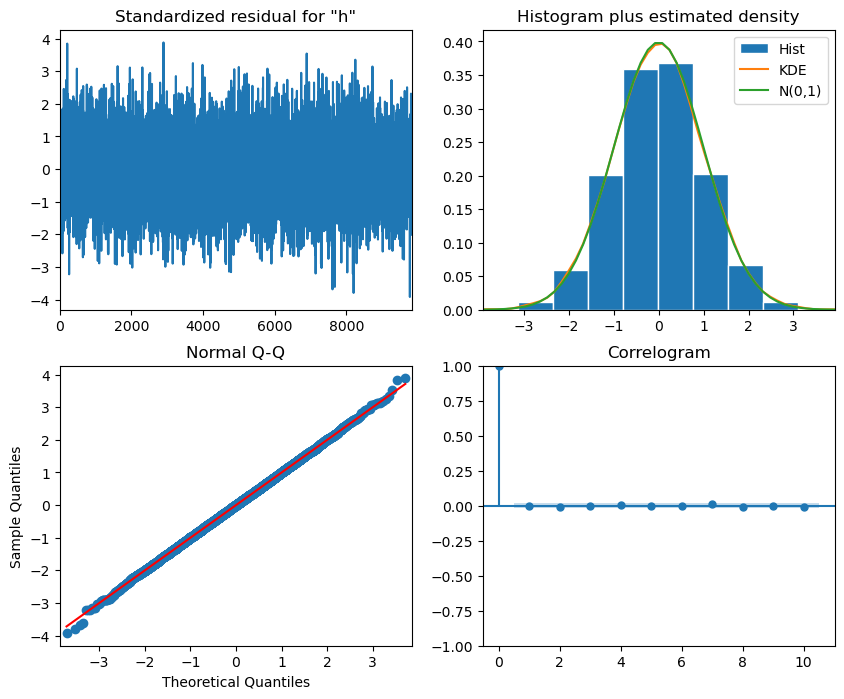

In [33]:
model_fit.plot_diagnostics(figsize = (10, 8))
plt.show()

In [34]:
residuals = model_fit.resid

rt = acorr_ljungbox(residuals, np.arange(1, 11, 1))

print(rt)

     lb_stat  lb_pvalue
1   0.001923   0.965020
2   0.005134   0.997436
3   0.025881   0.998901
4   0.025943   0.999917
5   0.026603   0.999994
6   0.049674   0.999997
7   0.057616   1.000000
8   0.060490   1.000000
9   0.063568   1.000000
10  0.065937   1.000000


In [35]:
def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, window: int, method: str, p = 0, d = 0, q = 0) -> list:
    '''
    df : 전체 시계열 데이터
    train_len : 훈련 집합의 크기
    horizon : 테스트 집합의 크기. 예측할 값의 개수
    window : 한 번에 예측할 timestep 개수
    method : 사용할 모델 지정
    p : AR 프로세스의 차수
    d : 차분 횟수
    q : MA 프로세스의 차수
    '''
    total_len = train_len + horizon

    if method == "mean":
        pred_mean = []

        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend([mean] * window)

        return pred_mean

    elif method == "last":
        pred_last_value = []

        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend([last_value] * window)

        return pred_last_value

    elif method == "ARIMA":
        pred_ARIMA = []

        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order = (p, d, q))
            res = model.fit(disp = False) # disp : 훈련 과정을 화면에 출력할지 여부
            predictions = res.get_prediction(0, i + window - 1) # start, end
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ARIMA.extend(oos_pred)

        return pred_ARIMA

In [36]:
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

p = 2
d = 1
q = 2

In [37]:
pred_ARIMA = rolling_forecast(df, TRAIN_LEN, HORIZON, WINDOW, "ARIMA", p, d, q)

In [38]:
mean_absolute_error(test["hourly_bandwidth"], pred_ARIMA)

1.3844224594736125